# <span style="color:blue">EVAC Workshop 2: GAs for classification</span>

**Module leader**

Simon O'Keefe: simon.okeefe@york.ac.uk

**Graduate Teaching Assistants**

Babar Khan: bk777@york.ac.uk

Tianda Sun: tianda.sun@york.ac.uk

## <span style="color:#0073e6">Prerequisites</span>

Before participating in this practical make sure that you have watched the the pre-workshop materials:
- Code walkthrough 3
- Code walkthrough 4

## <span style="color:#0073e6">Topics</span>

- Exploring data
- Cleaning data
- Balancing data
- Evolving a solution to classify on data

## <span style="color:#0073e6">Learning Objectives</span>

- To understand the basics of how to explore, clean, and balance data  
- To understand the challenges of training on data and making predictions  
- To understand the need to define your own representation for the problem with a GA  

# <span style="color:blue">Your Task</span>

Implement a genetic algorithm to classify different types of iris flowers. The classic dataset contains measurements of iris flowers, along with what type of flower they are. The idea is to classify whether the flower is a Versicolor (0), Setosa (1), or Virginica (2). Classify the flowers from the features in the data.

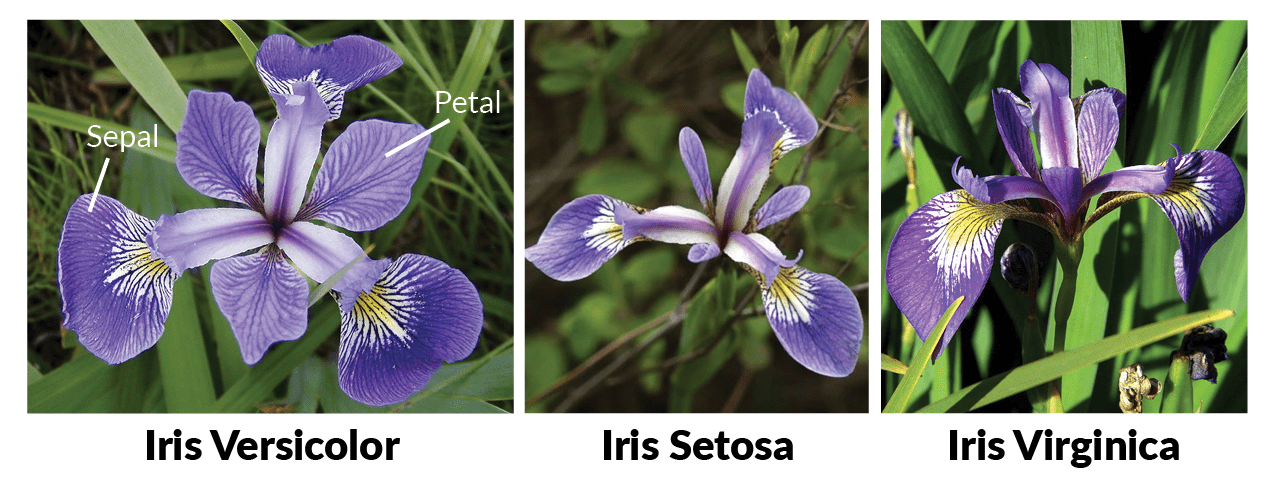

The approach is similar to that in walkthrough 3, but you should try to do this yourself, giving thought to what decisions are being made as you go through. You can reach to the notebook for walkthrough 3 when you need it.

**To keep things simple, you can remove one of the flowers and use a binary regression.**

However, if you would like to attempt a Softmax regression, after doing this, here is a good link to find out more:

https://github.com/rasbt/python-machine-learning-book/blob/master/code/bonus/softmax-regression.ipynb


Tips:
- Examine the data properly before implementing your algorithm.
- Use summary statistics and plots.
- Check for missing data and class imbalance.
- Explore different operators etc
- If you finish, you can find a dataset on Kaggle and have a go at a time-series regression problem (e.g. https://www.kaggle.com/bulentsiyah/for-simple-exercises-time-series-forecasting).

## <span style="color:#0073e6">Imports</span>

In [1]:
import random, math
import numpy as np
import pandas as pd
import seaborn as sns

from deap import base
from deap import creator
from deap import tools

from sklearn.datasets import load_iris
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import accuracy_score

## <span style="color:#0073e6">Reading the dataset</span>

In [2]:
iris = load_iris()

# Convert it into a Pandas dataframe
iris_data = pd.DataFrame(data= np.c_[iris['data'], iris['target']],
                     columns= iris['feature_names'] + ['target'])

## <span style="color:#0073e6">Exploring the dataset</span>

In [9]:
print(iris_data.info())
print(iris_data.target.value_counts())
print(iris_data.describe(include='all'))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    float64
dtypes: float64(5)
memory usage: 6.0 KB
None
target
0.0    50
1.0    50
2.0    50
Name: count, dtype: int64
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000 

<Axes: >

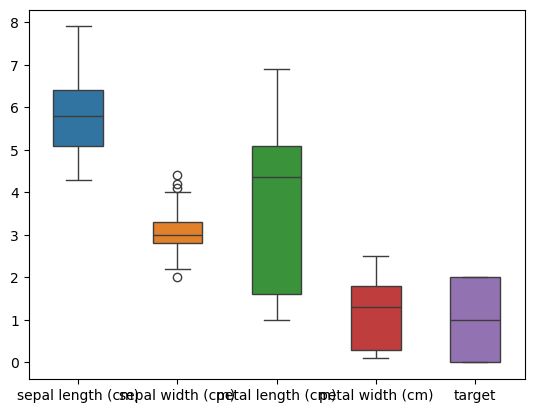

In [4]:
import seaborn as sns
sns.boxplot(data=iris_data.iloc[:,:], width=0.5)

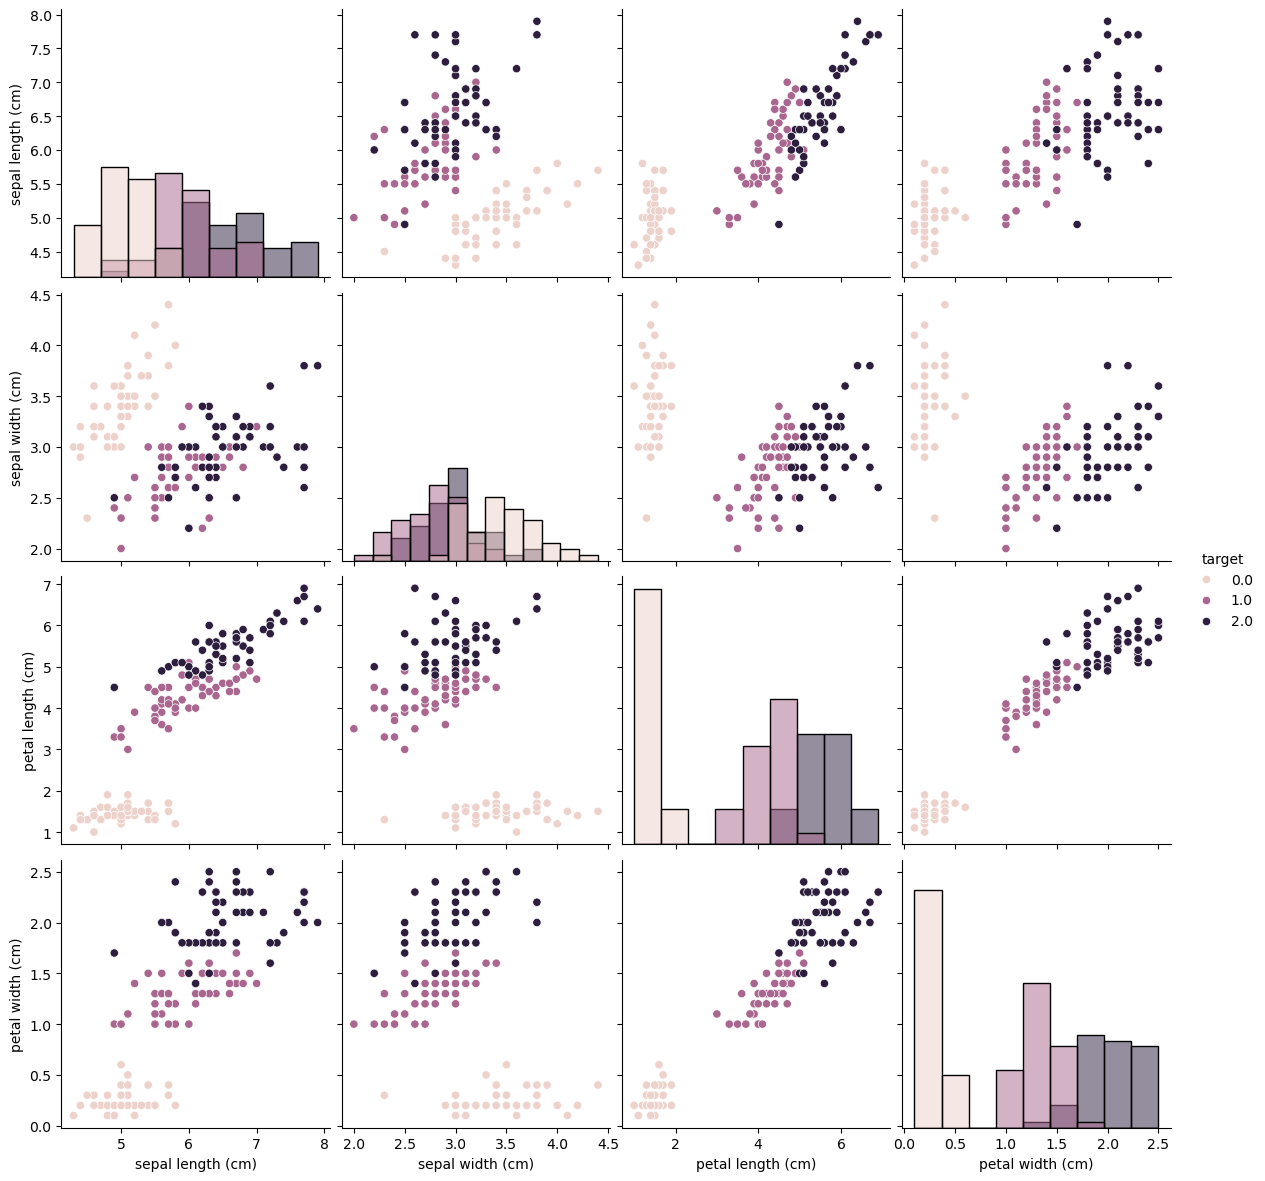

In [5]:
sns.pairplot(iris_data, hue="target", height=3, diag_kind="hist")

# <span style="color:blue">Add your GA code below</span>

## Create train/test splits

In [6]:
X = iris_data.drop(labels='target', axis=1)
y = iris_data['target']

In [8]:
ss = StratifiedShuffleSplit(n_splits = 1, test_size=0.3)
ss.get_n_splits(iris_data)

for train_index, test_index in ss.split(X,y):
    X_train = X.iloc[train_index]
    y_train = y.iloc[train_index]
    X_test = X.iloc[test_index]
    y_test = y.iloc[test_index]

print(y_train.value_counts())
print(y_test.value_counts())

target
2.0    35
0.0    35
1.0    35
Name: count, dtype: int64
target
1.0    15
0.0    15
2.0    15
Name: count, dtype: int64


## Evolutionary Algorithm

In [22]:
def sigmoid(x):
  return 1 / (1 + math.exp(-x))

def prediction(individual,row):
    regr = individual[0] + sum(i * r for i , r in zip(individual[1:4], row ) )
    return( float(sigmoid(regr)) )


def evalAccuracyTrain(individual, X_train, y_train):
    y_pred = [None] * X_train.shape[0]

    index = 0
    for i, row in X_train.iterrows():
        y_pred[index] = prediction(individual,row)
        index += 1

    # calculate mean squared difference (using the training set)
    diff = (np.array(y_pred) - np.array(y_train)) ** 2
    return( sum(diff), )

In [23]:
creator.create("FitnessMin", base.Fitness, weights=(-1.0,))
creator.create("Individual", list, fitness=creator.FitnessMin)
toolbox = base.Toolbox()
toolbox.register("attr_float", random.uniform, -1.0, 1.0)
toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_float, 5)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)
toolbox.register("evaluate", evalAccuracyTrain)
toolbox.register("mutate", tools.mutGaussian, mu=0.0, sigma=0.4, indpb=0.2)
toolbox.register("mate", tools.cxOnePoint)
toolbox.register("select", tools.selTournament, tournsize=3)

C:\Users\ej956\AppData\Roaming\Python\Python312\site-packages\deap\creator.py:185: RuntimeWarning: A class named 'FitnessMin' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "
C:\Users\ej956\AppData\Roaming\Python\Python312\site-packages\deap\creator.py:185: RuntimeWarning: A class named 'Individual' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "


In [24]:
NGEN, CXPB = 50, 0.2
pop = toolbox.population(n=200)

fitnesses = [toolbox.evaluate(ind, X_train, y_train) for ind in pop]
for ind, fit in zip(pop, fitnesses):
    ind.fitness.values = fit

In [25]:
for g in range(NGEN):
    print("-- Generation %i --" % g)
    offspring = toolbox.select(pop, len(pop))
    offspring = list(map(toolbox.clone, offspring))

    for child1, child2 in zip(offspring[::2], offspring[1::2]):
        if random.random() < CXPB:
            toolbox.mate(child1, child2)
            del child1.fitness.values
            del child2.fitness.values

    for mutant in offspring:
        toolbox.mutate(mutant)
        del mutant.fitness.values

    invalid_inds = [ind for ind in offspring if not ind.fitness.valid]
    fitnesses = [toolbox.evaluate(ind, X_train, y_train) for ind in invalid_inds]
    for ind, fit in zip(invalid_inds, fitnesses):
        ind.fitness.values = fit

    best_ind = tools.selBest(pop, 1)[0]
    # print("Best individual is %s, %s" % (best_ind, best_ind.fitness.values))
    pop[:] = offspring

-- Generation 0 --
-- Generation 1 --
-- Generation 2 --
-- Generation 3 --
-- Generation 4 --
-- Generation 5 --
-- Generation 6 --
-- Generation 7 --
-- Generation 8 --
-- Generation 9 --
-- Generation 10 --
-- Generation 11 --
-- Generation 12 --
-- Generation 13 --
-- Generation 14 --
-- Generation 15 --
-- Generation 16 --
-- Generation 17 --
-- Generation 18 --
-- Generation 19 --
-- Generation 20 --
-- Generation 21 --
-- Generation 22 --
-- Generation 23 --
-- Generation 24 --
-- Generation 25 --
-- Generation 26 --
-- Generation 27 --
-- Generation 28 --
-- Generation 29 --
-- Generation 30 --
-- Generation 31 --
-- Generation 32 --
-- Generation 33 --
-- Generation 34 --
-- Generation 35 --
-- Generation 36 --
-- Generation 37 --
-- Generation 38 --
-- Generation 39 --
-- Generation 40 --
-- Generation 41 --
-- Generation 42 --
-- Generation 43 --
-- Generation 44 --
-- Generation 45 --
-- Generation 46 --
-- Generation 47 --
-- Generation 48 --
-- Generation 49 --


In [26]:
y_pred = [None] * X_test.shape[0]
index = 0
for i, row in X_test.iterrows():
    y_pred[index] = prediction(best_ind,row)
    index += 1

y_bin_pred = np.array(y_pred) > 0.5
y_test_bin = np.array(y_test) > 0.5
accuracy = accuracy_score(y_test_bin, y_bin_pred)
print("Accuracy: %.2f%%" % (accuracy * 100.0))

Accuracy: 100.00%
